# Notebook 06 — Modelagem e Análise de Entropia

**Projeto:** Mineração de Dados em Saúde · PNS 2019
**Estudo:** Artrite e Reumatismo em Idosos Brasileiros
**Pesquisador:** Pedro Dias Soares
**Orientador:** Prof. Dr. Luis Enrique Zárate — PUC Minas (LICAP)

---

## O que este notebook faz (estado atual)

Implementa a **Análise de Entropia** (§3) sobre os datasets discretizados (saída do NB04), nos
**dois desenhos** (artrite pura · artrite + comorbidades). As seções de **modelagem** (modelos,
CV, comparação estatística, interpretabilidade) seguem o esqueleto de `proxima_fase.md` §2 e
entram em seguida — esta entrega consome o conjunto de atributos **selecionado pela entropia**.

## Metodologia de entropia (slides + artigos do orientador)

Os slides *Introdução15 (Entropia)* e *Introdução16 (Similaridade)* trazem **três usos** de
entropia: **(A)** entropia univariada H(X) para detectar atributo quase-constante; **(B)** poder
classificatório / **ganho de informação** IG = H(C)−H(C|A) para ranquear atributos *vs.* a classe;
**(C)** entropia de similaridade (Gower + Dash–Liu) para remover subconjuntos redundantes.

Dos 6 artigos do LICAP sobre a PNS, **nenhum** usou (C). O *paper-irmão* deste estudo
— **Artrite + Depressão (SBBD 2025)** — calculou a entropia *em relação à variável de classe*
(uso B) e, como os valores ficaram próximos, **manteve todos** os atributos; o de **Depressão**
removeu só 3 atributos degenerados (uso A). Seguimos o uso **(B)** como núcleo.

**Decisões fixadas para o NB06:**

| Decisão | Valor | Motivo |
|---|---|---|
| Camada de entropia | **1 — ranking supervisionado** (IG · Gain Ratio · **Incerteza Simétrica / SU**) | = art_d; SU normaliza a cardinalidade (atributos têm 2–22 níveis) |
| Papel | **Seleção** (remove atributos) | = art_c |
| Regra de corte | **Conservadora**: remove só **SU < `limiar_su`** (≈0 = sem informação de classe) | A base tem associação fraca (igual aos papers); cortar por significância removeria ~90% — indefensável |
| Base da medida | **Treino balanceado (RUS)** | No D1 (8,77:1) o desbalanceamento esmaga H(C)=0,48 e o IG; balancear traz H(C)≈1 e torna D1×D2 comparáveis |
| Permutação | **Coluna descritiva** (p-valor), **não** gatilho de remoção | Mostra honestamente que o sinal é fraco (ecoa art_d/art_b) |
| Vazamento | Seleção ajustada **só no treino** (teste *held-out*) | Padrão do projeto (cf. mediana in-fold do NB04) |

> Convenção de cor: <span style="color:#C0392B">**vermelho = Com Artrite**</span>,
> <span style="color:#27AE60">**verde = Saudável**</span>.

## 1 · Configuração

Lê o `config.toml` (fonte única). Os parâmetros da entropia estão na seção `[modelagem]`:
`test_size`, `limiar_su` (corte da seleção), `n_perm` (permutações) e `top_n_fig`. Os dois
desenhos apontam para o `dataset_discretizado.csv` de cada pasta do NB04; a saída vai para
`data/results/modelagem/`.

In [1]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

for _cat in (FutureWarning, DeprecationWarning, UserWarning):  # silencia avisos de depreciação (pandas/seaborn)
    warnings.filterwarnings('ignore', category=_cat)

# ── Configuração central (config.toml — fonte única) ──
try:
    import tomllib                       # Python 3.11+ (stdlib)
except ModuleNotFoundError:
    import tomli as tomllib              # Python 3.10: pip install tomli
with open('../config.toml', 'rb') as _f:
    CFG = tomllib.load(_f)

RANDOM_STATE = CFG['pipeline']['random_state']
ALPHA        = CFG['pipeline']['alpha']
MOD          = CFG['modelagem']
TEST_SIZE, LIMIAR_SU = MOD['test_size'], MOD['limiar_su']
N_PERM, TOP_N_FIG    = MOD['n_perm'], MOD['top_n_fig']
COR_ARTRITE  = CFG['cores']['artrite']    # vermelho
COR_SAUDAVEL = CFG['cores']['saudavel']   # verde

# ── Os dois desenhos: entrada = saída discretizada do NB04 ──
DESENHOS = {
    'd1': {'rotulo': 'Desenho 1 — Artrite pura',
           'entrada': '../data/results/discretizacao/dataset_discretizado.csv'},
    'd2': {'rotulo': 'Desenho 2 — Artrite + comorbidades',
           'entrada': '../data/results/discretizacao_comorbidades/dataset_discretizado.csv'},
}
DIR_SAIDA = '../data/results/modelagem/'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

def preparar_dirs(saida):
    figs, tabs = saida + 'figuras/', saida + 'tabelas/'
    for p in (saida, figs, tabs):
        os.makedirs(p, exist_ok=True)
    return figs, tabs

def salvar_fig(figs, nome):
    plt.savefig(figs + nome, dpi=150, bbox_inches='tight'); print(f'  \u2705 Figura \u2192 {figs+nome}')

def salvar_tab(tabs, df, nome):
    df.to_csv(tabs + nome, encoding='utf-8-sig');           print(f'  \u2705 Tabela \u2192 {tabs+nome}')

DIR_FIGURAS, DIR_TABELAS = preparar_dirs(DIR_SAIDA)
print(f'\u2705 Ambiente configurado. RANDOM_STATE={RANDOM_STATE}, ALPHA={ALPHA}')
print(f'   Seleção por entropia: limiar_su={LIMIAR_SU}, n_perm={N_PERM}, test_size={TEST_SIZE}')
print(f'   Saída: {DIR_SAIDA}')

✅ Ambiente configurado. RANDOM_STATE=42, ALPHA=0.05
   Seleção por entropia: limiar_su=0.001, n_perm=200, test_size=0.2
   Saída: ../data/results/modelagem/


## 2 · Carregamento e split 80/20 estratificado

Cada desenho é lido e dividido em treino/teste **estratificado** por classe (`random_state=42`).
A entropia é medida **só no treino** — o teste fica intocado (*held-out*), evitando vazamento na
etapa de seleção de atributos.

In [2]:
from sklearn.model_selection import train_test_split

DADOS = {}
for nome, cfg in DESENHOS.items():
    assert os.path.exists(cfg['entrada']), (
        f"Arquivo não encontrado: {cfg['entrada']}. Rode o NB04 (discretização) antes, "
        "ou copie data/results/ do repositório principal (é gitignored).")
    df = pd.read_csv(cfg['entrada'])
    y  = df['Label'].astype(int)
    X  = df.drop(columns=['Label']).copy()
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    DADOS[nome] = dict(Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, p=X.shape[1])
    print(f"[{nome}] {cfg['rotulo']}: {df.shape[0]:,}\u00d7{X.shape[1]}  "
          f"| treino {len(ytr):,} (0/1={dict(ytr.value_counts())}) "
          f"| teste {len(yte):,}")

[d1] Desenho 1 — Artrite pura: 4,826×59  | treino 3,860 (0/1={0: 3465, 1: 395}) | teste 966
[d2] Desenho 2 — Artrite + comorbidades: 8,357×56  | treino 6,685 (0/1={0: 3465, 1: 3220}) | teste 1,672


## 3 · Análise de Entropia (núcleo)

Mede, para cada atributo discretizado, **quanta incerteza da classe ele reduz**:

- **H(C)** — entropia da classe (em *bits*, log₂).
- **H(C|A)** = Σₐ P(a)·H(C|A=a) — entropia condicional.
- **IG(A)** = H(C) − H(C|A) — ganho de informação (= informação mútua).
- **Gain Ratio** = IG / H(A) — normaliza pela entropia do próprio atributo (Quinlan).
- **SU** = 2·IG / (H(C)+H(A)) ∈ [0,1] — **Incerteza Simétrica**: métrica primária, justa
  entre atributos de cardinalidades diferentes (aqui de 2 a 22 níveis).

Tudo medido sobre o **treino balanceado por RUS** (para H(C)≈1 e D1×D2 comparáveis). A coluna
`p_perm` (permutação de y) é **descritiva**: indica se a SU observada supera o acaso — mas a
remoção usa **apenas** o corte conservador `SU < limiar_su`.

### 3.1 · Funções de entropia

In [3]:
def entropia_shannon(serie):
    # H(X) em bits (log2). Mesma definição do NB04.
    p = pd.Series(np.asarray(serie)).value_counts(normalize=True, dropna=True)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

def entropia_condicional(y, a):
    # H(C|A) = soma_a P(a) * H(C | A=a). NaN do atributo vira uma categoria própria.
    df = pd.DataFrame({'y': np.asarray(y), 'a': pd.Series(np.asarray(a)).where(pd.notna(np.asarray(a)), 'NA__')})
    tot = len(df); h = 0.0
    for _, g in df.groupby('a', observed=True):
        h += (len(g) / tot) * entropia_shannon(g['y'])
    return h

def metricas_entropia(X, y):
    # Retorna DataFrame com IG, Gain Ratio e SU por atributo (ordenado por SU desc).
    Hc = entropia_shannon(y); rows = []
    for c in X.columns:
        a  = X[c]
        Ha = entropia_shannon(a)
        ig = Hc - entropia_condicional(y, a)
        gr = ig / Ha if Ha > 0 else 0.0
        su = 2 * ig / (Hc + Ha) if (Hc + Ha) > 0 else 0.0
        rows.append({'feature': c, 'k': int(pd.Series(a).nunique(dropna=True)),
                     'H_A': round(Ha, 3), 'IG': round(ig, 4),
                     'GainRatio': round(gr, 4), 'SU': round(su, 4)})
    return Hc, pd.DataFrame(rows).sort_values('SU', ascending=False).reset_index(drop=True)

def undersample(X, y, seed=RANDOM_STATE):
    # RUS: subamostra aleatória da(s) classe(s) maioritária(s) até o tamanho da minoritária.
    # (As seções de modelagem usarão imblearn.RandomUnderSampler in-fold dentro da CV.)
    rng = np.random.default_rng(seed)
    y = pd.Series(np.asarray(y), index=X.index)
    n = int(y.value_counts().min()); idx = []
    for cls in sorted(y.unique()):
        ci = y.index[y == cls].to_numpy()
        idx.append(rng.choice(ci, n, replace=False))
    idx = np.concatenate(idx)
    return X.loc[idx], y.loc[idx]

def pvalor_permutacao(X, y, su_obs, n_perm=N_PERM, seed=RANDOM_STATE):
    # p-valor descritivo por atributo: fração de permutações de y cuja SU >= SU observada.
    rng = np.random.default_rng(seed)
    yv = np.asarray(y)
    ge = pd.Series(0, index=su_obs.index, dtype=float)
    for _ in range(n_perm):
        _, t = metricas_entropia(X, rng.permutation(yv))
        su_p = t.set_index('feature')['SU'].reindex(su_obs.index).fillna(0.0)
        ge += (su_p.values >= su_obs.values).astype(float)
    return ((ge + 1) / (n_perm + 1)).round(4)   # +1: estimador conservador de p

print('  \u2705 Funções de entropia definidas.')

  ✅ Funções de entropia definidas.


### 3.2 · Ranking e seleção por desenho

Para cada desenho: balanceia o treino (RUS), calcula as métricas, anexa o `p_perm` descritivo e
aplica o corte conservador. `decisao = 'remover'` ⇔ `SU < limiar_su`. O conjunto **mantido**
(`features_selecionadas`) é o que alimenta a modelagem.

In [4]:
RESULT = {}
for nome, cfg in DESENHOS.items():
    Xtr, ytr = DADOS[nome]['Xtr'], DADOS[nome]['ytr']
    Hc_nat   = entropia_shannon(ytr)                 # H(C) na distribuição natural (desbalanceada)
    Xb, yb   = undersample(Xtr, ytr)                 # treino balanceado (RUS)
    Hc_bal, tab = metricas_entropia(Xb, yb)          # métricas sobre o treino balanceado
    tab['p_perm']       = pvalor_permutacao(Xb, yb, tab.set_index('feature')['SU']).values
    tab['significativo'] = tab['p_perm'] < ALPHA
    tab['decisao']       = np.where(tab['SU'] < LIMIAR_SU, 'remover', 'manter')

    mantidas = tab.loc[tab.decisao == 'manter', 'feature'].tolist()
    removidas = tab.loc[tab.decisao == 'remover', 'feature'].tolist()
    RESULT[nome] = dict(Hc_nat=Hc_nat, Hc_bal=Hc_bal, n_bal=len(yb),
                        tabela=tab, mantidas=mantidas, removidas=removidas)

    print(f"\n\u2550\u2550 [{nome}] {cfg['rotulo']} \u2550\u2550")
    print(f"   H(Classe): natural={Hc_nat:.3f}  |  balanceada(RUS)={Hc_bal:.3f} bits  (n_bal={len(yb):,})")
    print(f"   Mantidos: {len(mantidas)}  |  Removidos (SU<{LIMIAR_SU}): {len(removidas)}")
    print(f"   Significativos vs. acaso (p<{ALPHA}): {int(tab['significativo'].sum())}/{len(tab)}")
    salvar_tab(DIR_TABELAS, tab.set_index('feature'), f'entropia_ranking_{nome}.csv')
    print('   Removidos:', removidas)
    display(tab.head(12))


══ [d1] Desenho 1 — Artrite pura ══
   H(Classe): natural=0.476  |  balanceada(RUS)=1.000 bits  (n_bal=790)
   Mantidos: 39  |  Removidos (SU<0.001): 20
   Significativos vs. acaso (p<0.05): 16/59
  ✅ Tabela → ../data/results/modelagem/tabelas/entropia_ranking_d1.csv
   Removidos: ['P02101_Normal', 'J01101_Mais de 2 anos a 3 anos', 'P00615_Sim', 'P034_Sim', 'P02401_Integral', 'G062_Não', 'P02601_Alto', 'P02801_cat', 'P013_cat', 'P02601_Baixo', 'P027_Uma vez ou mais por mês', 'P03201_Não', 'P02601_Muito alto', 'J01002_Outro serviço', 'J01002_Farmácia', 'J01002_Atendimento domiciliar', 'P00614_Sim', 'P00612_Sim', 'P02101_Diet/Light/Zero', 'P00620_Sim']


,feature,k,H_A,IG,GainRatio,SU,p_perm,significativo,decisao
0,Q084_Sim,2,0.850,0.0304,0.0358,0.0329,0.0050,True,manter
1,N010,4,1.368,0.0373,0.0273,0.0315,0.0050,True,manter
2,C006_Mulher,2,0.995,0.0308,0.0309,0.0308,0.0050,True,manter
3,N011,4,1.076,0.0300,0.0279,0.0289,0.0050,True,manter
4,N001,5,1.733,0.0311,0.0179,0.0227,0.0050,True,manter
5,G081,4,0.783,0.0199,0.0254,0.0223,0.0050,True,manter
6,J012_cat,4,1.831,0.0287,0.0157,0.0203,0.0050,True,manter
7,Q05901,6,2.099,0.0288,0.0137,0.0186,0.0050,True,manter
8,J01101_Mais de 1 ano a 2 anos,2,0.457,0.0106,0.0233,0.0146,0.0050,True,manter
9,J01002_Unidade básica de saúde (posto ou centr...,2,0.952,0.0096,0.0101,0.0098,0.0050,True,manter



══ [d2] Desenho 2 — Artrite + comorbidades ══
   H(Classe): natural=0.999  |  balanceada(RUS)=1.000 bits  (n_bal=6,440)
   Mantidos: 43  |  Removidos (SU<0.001): 13
   Significativos vs. acaso (p<0.05): 44/56
  ✅ Tabela → ../data/results/modelagem/tabelas/entropia_ranking_d2.csv
   Removidos: ['G062_Não', 'J01002_Policlínica pública, PAM (Posto de Assistência Médica) ou Centro de Especialidades público', 'VDF004', 'P00615_Sim', 'J01002_UPA (Unidade de Pronto Atendimento), outro tipo de pronto atendimento público (24 horas), pronto-socorro ou emergência de hospital público.', 'P02602_cat', 'P02601_Muito alto', 'J01002_Farmácia', 'J01002_Atendimento domiciliar', 'P034_Sim', 'P02401_Os dois tipos', 'P02601_Alto', 'J01002_Outro serviço']


,feature,k,H_A,IG,GainRatio,SU,p_perm,significativo,decisao
0,C006_Mulher,2,0.969,0.0997,0.1029,0.1013,0.005,True,manter
1,J012_cat,4,1.885,0.1412,0.0749,0.0979,0.005,True,manter
2,Q084_Sim,2,0.931,0.0946,0.1015,0.0979,0.005,True,manter
3,N001,5,1.849,0.1303,0.0704,0.0914,0.005,True,manter
4,N011,4,1.424,0.0979,0.0688,0.0808,0.005,True,manter
5,N010,4,1.603,0.0964,0.0601,0.0740,0.005,True,manter
6,G081,4,0.975,0.0665,0.0682,0.0673,0.005,True,manter
7,J01101_Mais de 3 anos,2,0.347,0.0325,0.0938,0.0483,0.005,True,manter
8,J01101_Mais de 1 ano a 2 anos,2,0.398,0.0269,0.0677,0.0385,0.005,True,manter
9,G062_Sim,2,0.328,0.0237,0.0723,0.0358,0.005,True,manter


### 3.3 · Figura — ranking por Incerteza Simétrica (top-N)

  ✅ Figura → ../data/results/modelagem/figuras/entropia_ranking_su.png


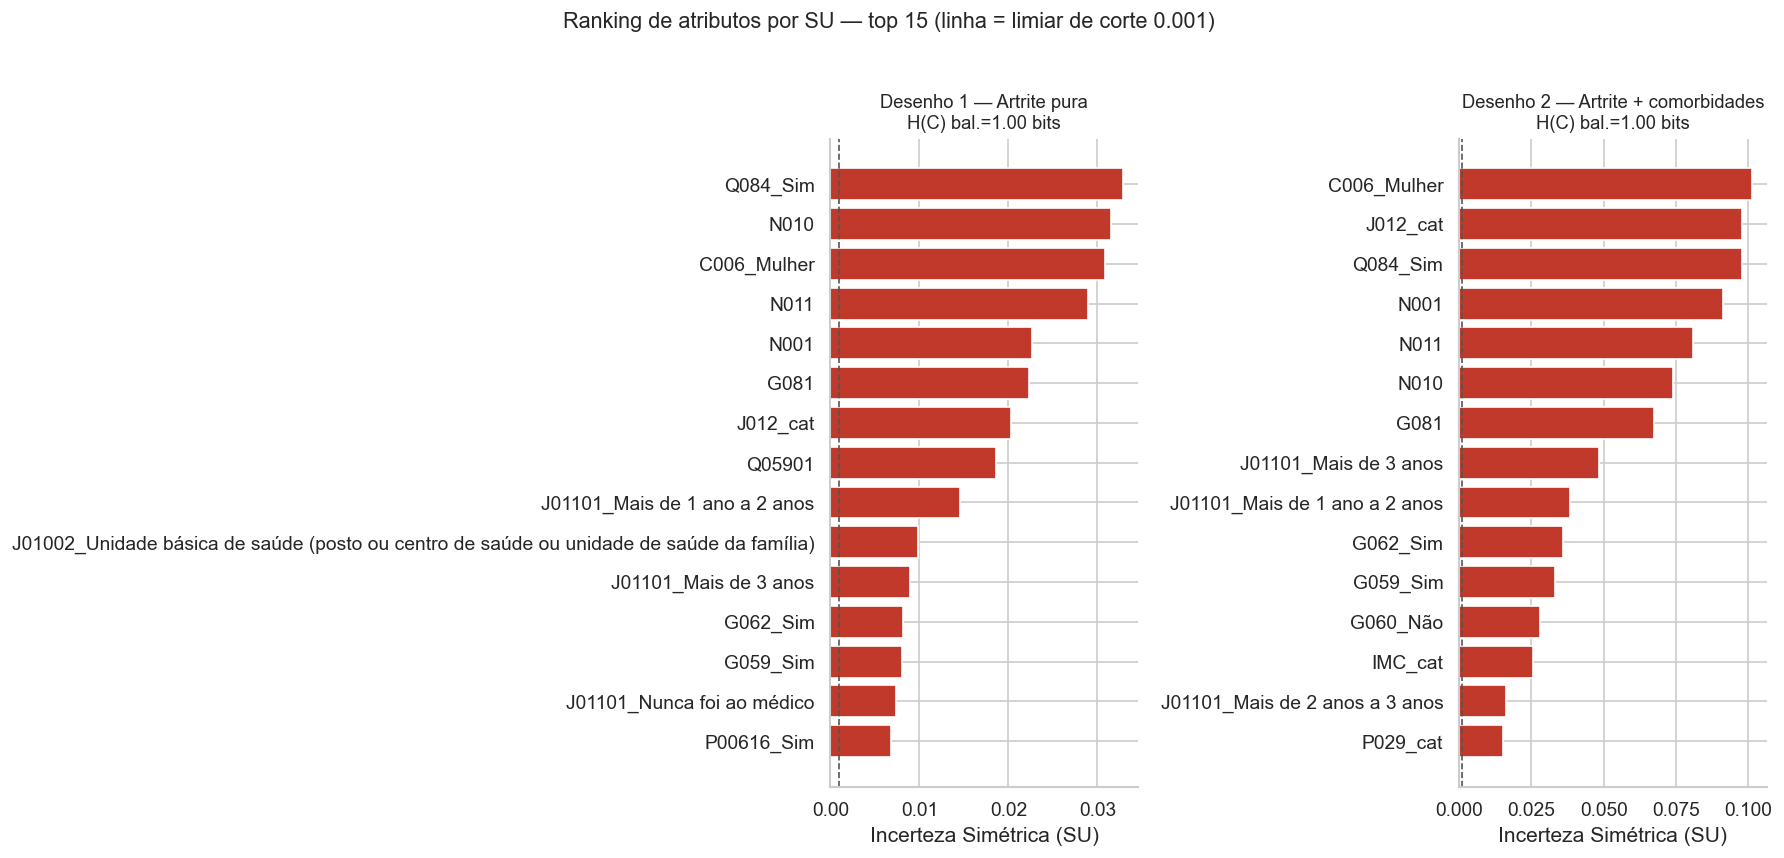

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (nome, cfg) in zip(axes, DESENHOS.items()):
    tab = RESULT[nome]['tabela'].head(TOP_N_FIG).iloc[::-1]
    cores = np.where(tab['decisao'] == 'manter', COR_ARTRITE, '#BBBBBB')
    ax.barh(tab['feature'], tab['SU'], color=cores)
    ax.axvline(LIMIAR_SU, ls='--', lw=1, color='#555555')
    ax.set_title(f"{cfg['rotulo']}\nH(C) bal.={RESULT[nome]['Hc_bal']:.2f} bits", fontsize=11)
    ax.set_xlabel('Incerteza Simétrica (SU)')
fig.suptitle(f'Ranking de atributos por SU — top {TOP_N_FIG} (linha = limiar de corte {LIMIAR_SU})',
             fontsize=13, y=1.02)
plt.tight_layout()
salvar_fig(DIR_FIGURAS, 'entropia_ranking_su.png')
plt.show()

### 3.4 · Exportação do relatório de entropia

In [6]:
relatorio = {
    'notebook': '06_modelagem_ml — Análise de Entropia',
    'pesquisador': 'Pedro Dias Soares',
    'orientador': 'Prof. Dr. Luis Enrique Zárate — PUC Minas',
    'metodo': ('Camada 1 (ranking supervisionado IG/GainRatio/SU, = art_d) com seleção '
               'conservadora (= art_c): remove SU<limiar_su sobre o treino balanceado por RUS; '
               'permutação como p-valor descritivo. Seleção ajustada só no treino.'),
    'parametros': {'RANDOM_STATE': RANDOM_STATE, 'ALPHA': ALPHA, 'TEST_SIZE': TEST_SIZE,
                   'LIMIAR_SU': LIMIAR_SU, 'N_PERM': N_PERM},
    'desenhos': {}}
for nome, cfg in DESENHOS.items():
    r = RESULT[nome]
    relatorio['desenhos'][nome] = {
        'rotulo': cfg['rotulo'],
        'H_classe_natural': round(r['Hc_nat'], 4),
        'H_classe_balanceada': round(r['Hc_bal'], 4),
        'n_treino_balanceado': int(r['n_bal']),
        'n_mantidos': len(r['mantidas']), 'n_removidos': len(r['removidas']),
        'features_selecionadas': r['mantidas'], 'features_removidas': r['removidas'],
        'ranking': r['tabela'].to_dict('records')}
with open(DIR_SAIDA + 'relatorio_entropia.json', 'w', encoding='utf-8') as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)
print(f'  \u2705 Relatório \u2192 {DIR_SAIDA}relatorio_entropia.json')

# Conjuntos prontos para a modelagem:
features_selecionadas = {nome: RESULT[nome]['mantidas'] for nome in DESENHOS}
print('  Atributos para a modelagem:',
      {k: len(v) for k, v in features_selecionadas.items()})

  ✅ Relatório → ../data/results/modelagem/relatorio_entropia.json
  Atributos para a modelagem: {'d1': 39, 'd2': 43}


## 4 · Modelagem supervisionada — Ablação por blocos

> **Pergunta de pesquisa:** *Quais **padrões nutricionais** e **características sociodemográficas**
> diferenciam, no Brasil, os idosos com artrite dos idosos saudáveis (PNS 2019), via algoritmos
> supervisionados?*

O modelo é um **instrumento descritivo** (regras + ranking de fatores, estilo LICAP/Zárate), não um
classificador de produção. Para responder *quanto* e *quais* fatores diferenciam, usamos a
**ablação por blocos** — a mesma manobra do paper de TOC (Puga & Zárate, SBBD 2024), que mediu o
ganho de F1 ao adicionar um bloco de atributos. Aqui medimos o **ganho marginal da nutrição**:

| Conjunto | Atributos | O que mede |
|---|---|---|
| **M0** | só **sociodemográfico** (sexo, idade, renda, escolaridade) | linha de base "quem é a pessoa" |
| **M1** | só **nutrição** | poder isolado da dieta |
| **M2** | **socio + nutrição** | **conjunto-resposta**; ganho da dieta sobre M0 |
| **Mc** | **socio + controle** (saúde percebida, limitação, comorbidade, uso de serviço, álcool, IMC) | base sem dieta, com confundidores |
| **M3** | **socio + nutrição + controle** (completo) | ganho da dieta sobre Mc |

$$\Delta F1_{\text{nutrição}|\text{socio}} = F1(M2)-F1(M0) \qquad \Delta F1_{\text{nutrição}|\text{socio+ctrl}} = F1(M3)-F1(Mc)$$

**Eixo nutricional "os três juntos"** (decisão do projeto): itens de frequência discretizados (no
dataset) **+ IRNI** contínuo (índice inflamatório, proxy do DII) **+ Cluster alimentar** (k-means).
IRNI e Cluster são calculados **in-fold** (z-score e k-means ajustados só no treino do fold, dentro
do `imblearn.Pipeline`) a partir das frequências cruas — sem vazamento. O quadrante
`Padrao_Alimentar` é **aposentado** (spec §0: evita colinearidade com IRNI+cluster).

**Algoritmos (LICAP):** Árvore de Decisão (regras), Floresta Aleatória (desempenho/importância),
Naïve-Bayes e Regressão Logística (OR ajustado). RUS **in-fold**; teste *held-out* desbalanceado.
A lógica testável vive em [`modelagem.py`](modelagem.py) (mesmo padrão de `nutricao.py`); este
notebook orquestra e visualiza. Parâmetros em `config.toml [modelagem]`.

> ⏱️ A seção 4.2 roda `RandomizedSearchCV` para ~12 combinações por desenho — **alguns minutos**.

In [7]:
### 4.1 · Configuração da ablação: blocos, frequências cruas e k do cluster
import importlib, modelagem as mdl, nutricao as nut
importlib.reload(nut); importlib.reload(mdl)   # garante a versão atual dos helpers
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

# ── parâmetros (config.toml [modelagem] + [nutricao]) ──
N_ITER   = MOD.get('n_iter_busca', 15)
CV_BUSCA = MOD.get('cv_busca', 5)
CV_AVAL  = MOD.get('cv_aval', 10)
MIN_COB  = MOD.get('min_cobertura_regra', 0.10)
ITENS_IRNI = CFG['nutricao']['irni']['itens_frequencia']
PESOS_G    = dict(CFG['nutricao']['irni']['graded'])
PESOS_D    = dict(CFG['nutricao']['irni']['direcao'])

# ── caminhos das frequências cruas (pré-discretização) por desenho ──
PREP = {'d1': '../data/results/preprocessing/dataset_preprocessado.csv',
        'd2': '../data/results/preprocessing_comorbidades/dataset_preprocessado.csv'}

# Conjuntos de ablação (ordem fixa) e a matriz de execução:
# RF e DT em TODOS os conjuntos (curva de ablação); NB e LogReg só no conjunto-resposta M2.
ORDEM_SETS = ['M0_socio', 'M1_nutri', 'M2_socio_nutri', 'Mc_socio_ctrl', 'M3_completo']
COMBOS = {'rf': ORDEM_SETS, 'dt': ORDEM_SETS, 'nb': ['M2_socio_nutri'], 'logreg': ['M2_socio_nutri']}
ROTULO_MODELO = {'rf': 'Floresta Aleatória', 'dt': 'Árvore de Decisão',
                 'nb': 'Naïve-Bayes', 'logreg': 'Regressão Logística'}

DESIGN = {}
for nome, cfg in DESENHOS.items():
    X, y, blocos, raw_cols = mdl.carregar_design(cfg['entrada'], PREP[nome], ITENS_IRNI)
    # filtro de continuidade com a §3: mantém só os atributos discretizados selecionados pela entropia
    if nome in RESULT:
        mantidas = {c.lstrip('﻿') for c in RESULT[nome]['mantidas']}
        disc_cols = [c for c in X.columns if not c.startswith(mdl.PREFIXO_RAW)]
        manter = [c for c in disc_cols if c in mantidas] + list(raw_cols)
        X = X[manter]
        blocos = mdl.montar_blocos([c for c in X.columns if not c.startswith(mdl.PREFIXO_RAW)])
    conj = mdl.conjuntos_ablacao(blocos)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    k, tab_sil = mdl.escolher_k_descritivo(Xtr, raw_cols, PESOS_D,
                                           k_min=CFG['nutricao']['cluster']['k_min'],
                                           k_max=CFG['nutricao']['cluster']['k_max'],
                                           random_state=RANDOM_STATE)
    DESIGN[nome] = dict(X=X, y=y, Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte, blocos=blocos,
                        conj=conj, raw_cols=raw_cols, k=k, tab_sil=tab_sil, rotulo=cfg['rotulo'])
    print(f"══ [{nome}] {cfg['rotulo']} ══")
    print(f"   blocos: socio={len(blocos['socio'])}  nutri={len(blocos['nutri'])}  "
          f"control={len(blocos.get('control', []))}  | aposentado(Padrao)={len(blocos.get('retirar', []))}")
    print(f"   socio = {sorted({mdl.var_pai(c) for c in blocos['socio']})}")
    print(f"   nutri = {sorted({mdl.var_pai(c) for c in blocos['nutri']})}  (+ IRNI_graded + Cluster_Alimentar in-fold)")
    print(f"   k_cluster (silhueta) = {k}  | silhuetas {tab_sil}")
    print(f"   treino {len(ytr):,} (0/1={dict(ytr.value_counts())})  |  teste {len(yte):,}\n")
print(f"✅ Ablação configurada: N_ITER={N_ITER}, CV_BUSCA={CV_BUSCA}, CV_AVAL={CV_AVAL}, min_cobertura={MIN_COB}")

══ [d1] Desenho 1 — Artrite pura ══
   blocos: socio=4  nutri=8  control=26  | aposentado(Padrao)=0
   socio = ['C006', 'C008', 'VDD004A', 'VDF004']
   nutri = ['P006', 'P00603', 'P00616', 'P02102', 'P02401', 'P02601', 'P02602']  (+ IRNI_graded + Cluster_Alimentar in-fold)
   k_cluster (silhueta) = 6  | silhuetas {2: 0.1093, 3: 0.1005, 4: 0.1099, 5: 0.1044, 6: 0.1167}
   treino 3,860 (0/1={0: 3465, 1: 395})  |  teste 966



══ [d2] Desenho 2 — Artrite + comorbidades ══
   blocos: socio=3  nutri=12  control=27  | aposentado(Padrao)=0
   socio = ['C006', 'C008', 'VDD004A']
   nutri = ['P006', 'P00603', 'P00612', 'P00614', 'P00616', 'P00620', 'P013', 'P02102', 'P02401', 'P02601']  (+ IRNI_graded + Cluster_Alimentar in-fold)
   k_cluster (silhueta) = 2  | silhuetas {2: 0.1126, 3: 0.1013, 4: 0.1109, 5: 0.1062, 6: 0.0932}
   treino 6,685 (0/1={0: 3465, 1: 3220})  |  teste 1,672

✅ Ablação configurada: N_ITER=15, CV_BUSCA=5, CV_AVAL=10, min_cobertura=0.1


### 4.2 · Treino, busca de hiperparâmetros e avaliação por fold

Para cada desenho × conjunto × modelo: `RandomizedSearchCV` (5-fold, `scoring='f1'`) escolhe os
hiperparâmetros; o melhor estimador é avaliado por **10-fold CV** (Acc, Precisão, Recall, F1, AUC —
média ± IC95%, padrão dos papers do Zárate) e no **teste *held-out*** desbalanceado. Tudo dentro do
`imblearn.Pipeline` com **RUS in-fold** e IRNI/Cluster ajustados só no treino. *(Roda alguns minutos.)*

In [8]:
import time
RESULT_MOD = {}                      # RESULT_MOD[desenho][(modelo, conjunto)] = {cv, holdout, best}
linhas_metricas = []                 # tabela tidy p/ exportar
for nome in DESIGN:
    D = DESIGN[nome]; RESULT_MOD[nome] = {}; t0 = time.time()
    print(f"══ [{nome}] {D['rotulo']} ══")
    for modelo, sets in COMBOS.items():
        for s in sets:
            Xs    = mdl.selecionar_X(D['Xtr'], D['conj'][s], D['raw_cols'])
            Xs_te = mdl.selecionar_X(D['Xte'], D['conj'][s], D['raw_cols'])
            pipe  = mdl.build_pipeline(modelo, D['conj'][s]['tem_nutri'],
                                       PESOS_G, PESOS_D, k=D['k'], random_state=RANDOM_STATE)
            busca = RandomizedSearchCV(pipe, mdl.espaco_busca(modelo), n_iter=N_ITER, scoring='f1',
                                       cv=StratifiedKFold(CV_BUSCA, shuffle=True, random_state=RANDOM_STATE),
                                       random_state=RANDOM_STATE, n_jobs=-1, error_score='raise')
            busca.fit(Xs, D['ytr'])
            best = busca.best_estimator_
            cv   = mdl.metricas_cv(best, Xs, D['ytr'], n_splits=CV_AVAL, random_state=RANDOM_STATE)
            hold = mdl.avaliar_holdout(best, Xs, D['ytr'], Xs_te, D['yte'])
            RESULT_MOD[nome][(modelo, s)] = dict(cv=cv, holdout=hold, best=busca.best_params_)
            linhas_metricas.append({
                'desenho': nome, 'modelo': modelo, 'conjunto': s,
                'f1_cv': cv['f1']['media'], 'f1_ic_lo': cv['f1']['ic_lo'], 'f1_ic_hi': cv['f1']['ic_hi'],
                'auc_cv': cv['auc']['media'], 'rec_cv': cv['rec']['media'], 'prec_cv': cv['prec']['media'],
                'acc_cv': cv['acc']['media'], 'f1_teste': hold['f1'], 'auc_teste': hold['auc']})
            print(f"   {ROTULO_MODELO[modelo][:14]:14s} {s:16s} | CV F1={cv['f1']['media']:.3f} "
                  f"[{cv['f1']['ic_lo']:.3f}-{cv['f1']['ic_hi']:.3f}] AUC={cv['auc']['media']:.3f} "
                  f"| teste F1={hold['f1']:.3f} AUC={hold['auc']:.3f}")
    print(f"   ⏱️ {time.time()-t0:.0f}s\n")

tab_metricas = pd.DataFrame(linhas_metricas)
salvar_tab(DIR_TABELAS, tab_metricas.set_index(['desenho', 'modelo', 'conjunto']), 'modelagem_metricas.csv')
print('✅ Ablação concluída.')

══ [d1] Desenho 1 — Artrite pura ══


   Floresta Aleat M0_socio         | CV F1=0.233 [0.216-0.249] AUC=0.603 | teste F1=0.257 AUC=0.642


   Floresta Aleat M1_nutri         | CV F1=0.210 [0.190-0.230] AUC=0.574 | teste F1=0.197 AUC=0.529


   Floresta Aleat M2_socio_nutri   | CV F1=0.222 [0.203-0.241] AUC=0.626 | teste F1=0.238 AUC=0.632


   Floresta Aleat Mc_socio_ctrl    | CV F1=0.289 [0.264-0.314] AUC=0.720 | teste F1=0.310 AUC=0.758


...

   Árvore de Deci M2_socio_nutri   | CV F1=0.690 [0.683-0.697] AUC=0.710 | teste F1=0.690 AUC=0.710


   Árvore de Deci Mc_socio_ctrl    | CV F1=0.768 [0.758-0.778] AUC=0.849 | teste F1=0.762 AUC=0.851


   Árvore de Deci M3_completo      | CV F1=0.766 [0.755-0.777] AUC=0.846 | teste F1=0.756 AUC=0.846


   Naïve-Bayes    M2_socio_nutri   | CV F1=0.528 [0.502-0.554] AUC=0.697 | teste F1=0.545 AUC=0.712


   Regressão Logí M2_socio_nutri   | CV F1=0.692 [0.682-0.701] AUC=0.726 | teste F1=0.695 AUC=0.734
   ⏱️ 283s

  ✅ Tabela → ../data/results/modelagem/tabelas/modelagem_metricas.csv
✅ Ablação concluída.


### 4.3 · Ganho marginal da nutrição (ΔF1 · ΔAUC) — a resposta quantitativa

Esta é a métrica que responde diretamente *"quanto a dieta adiciona"*. Comparamos o desempenho ao
**acrescentar o bloco nutricional**: sobre o sociodemográfico (M2−M0) e sobre o sociodemográfico +
controle (M3−Mc). Um Δ próximo de zero (com IC95% cruzando os vizinhos) = a nutrição **não**
diferencia além do que sexo/idade e o estado de saúde já explicam.

  ✅ Tabela → ../data/results/modelagem/tabelas/modelagem_delta_nutricao.csv


,desenho,modelo,dF1_sobre_socio,dAUC_sobre_socio,dF1_sobre_socio_ctrl,dAUC_sobre_socio_ctrl
0,d1,Floresta Aleatória,-0.010,0.022,-0.002,0.002
1,d1,Árvore de Decisão,-0.002,0.004,0.000,-0.009
2,d2,Floresta Aleatória,0.008,0.012,0.005,0.001
3,d2,Árvore de Decisão,0.002,0.001,-0.002,-0.003


  ✅ Figura → ../data/results/modelagem/figuras/modelagem_ablacao_f1.png


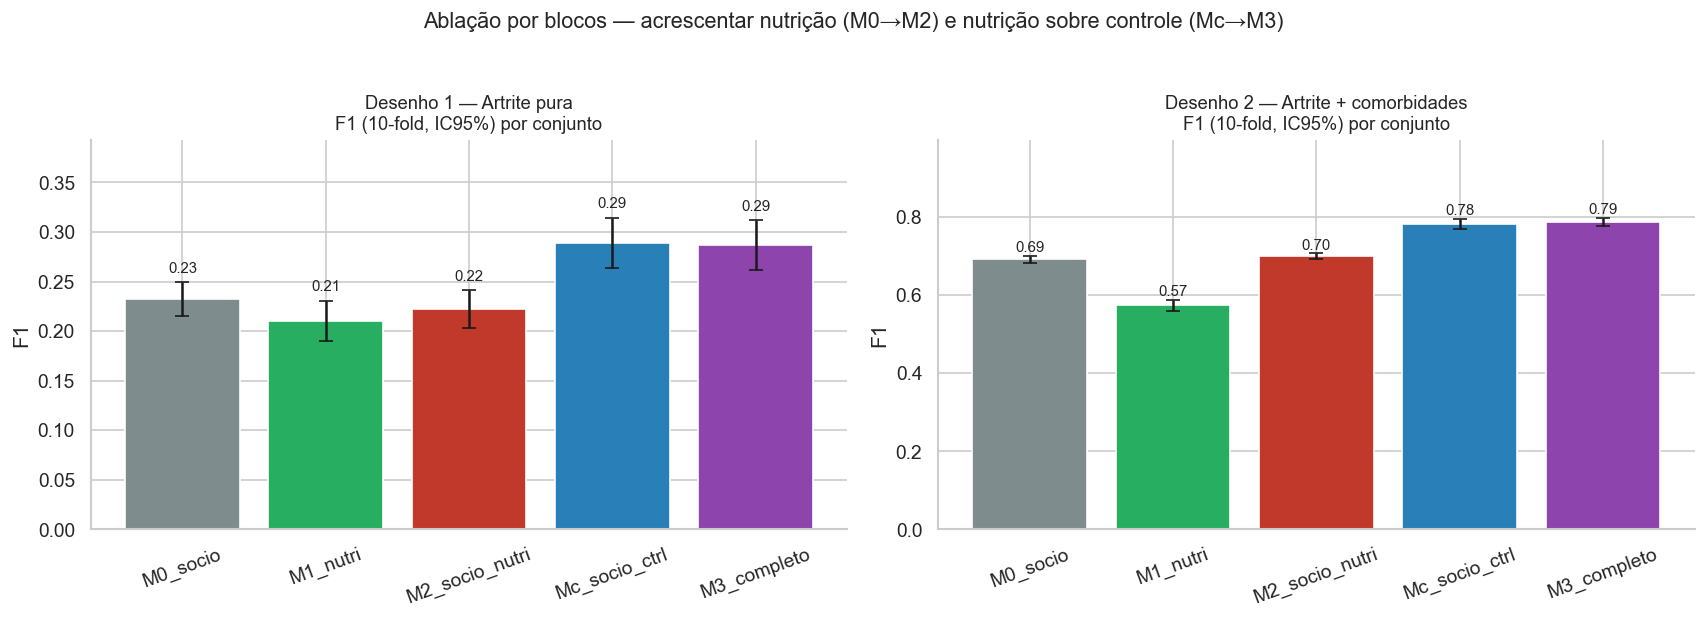

In [9]:
def _cv(nome, modelo, s, met): return RESULT_MOD[nome][(modelo, s)]['cv'][met]['media']

# Tabela de Δ marginal da nutrição (RF = melhor desempenho; DT = interpretável)
linhas_delta = []
for nome in DESIGN:
    for modelo in ['rf', 'dt']:
        linhas_delta.append({
            'desenho': nome, 'modelo': ROTULO_MODELO[modelo],
            'dF1_sobre_socio':  _cv(nome, modelo, 'M2_socio_nutri', 'f1') - _cv(nome, modelo, 'M0_socio', 'f1'),
            'dAUC_sobre_socio': _cv(nome, modelo, 'M2_socio_nutri', 'auc') - _cv(nome, modelo, 'M0_socio', 'auc'),
            'dF1_sobre_socio_ctrl':  _cv(nome, modelo, 'M3_completo', 'f1') - _cv(nome, modelo, 'Mc_socio_ctrl', 'f1'),
            'dAUC_sobre_socio_ctrl': _cv(nome, modelo, 'M3_completo', 'auc') - _cv(nome, modelo, 'Mc_socio_ctrl', 'auc')})
tab_delta = pd.DataFrame(linhas_delta).round(3)
salvar_tab(DIR_TABELAS, tab_delta.set_index(['desenho', 'modelo']), 'modelagem_delta_nutricao.csv')
display(tab_delta)

# Figura: F1 (com IC95) ao longo dos conjuntos de ablação — RF, um painel por desenho
fig, axes = plt.subplots(1, len(DESIGN), figsize=(7.2 * len(DESIGN), 5), squeeze=False)
for ax, nome in zip(axes[0], DESIGN):
    f1  = [_cv(nome, 'rf', s, 'f1') for s in ORDEM_SETS]
    lo  = [RESULT_MOD[nome][('rf', s)]['cv']['f1']['ic_lo'] for s in ORDEM_SETS]
    hi  = [RESULT_MOD[nome][('rf', s)]['cv']['f1']['ic_hi'] for s in ORDEM_SETS]
    err = [np.array(f1) - np.array(lo), np.array(hi) - np.array(f1)]
    cores = ['#7f8c8d', '#27AE60', '#C0392B', '#2980B9', '#8E44AD']  # M0,M1,M2,Mc,M3
    ax.bar(ORDEM_SETS, f1, yerr=err, capsize=4, color=cores)
    for i, v in enumerate(f1):
        ax.text(i, hi[i] + 0.01, f'{v:.2f}', ha='center', fontsize=9)
    ax.set_title(f"{DESIGN[nome]['rotulo']}\nF1 (10-fold, IC95%) por conjunto", fontsize=11)
    ax.set_ylabel('F1'); ax.set_ylim(0, max(hi) * 1.25)
    ax.tick_params(axis='x', rotation=20)
fig.suptitle('Ablação por blocos — acrescentar nutrição (M0→M2) e nutrição sobre controle (Mc→M3)',
             fontsize=13, y=1.03)
plt.tight_layout(); salvar_fig(DIR_FIGURAS, 'modelagem_ablacao_f1.png'); plt.show()

### 4.4 · Avaliação no teste *held-out* (matriz de confusão + ROC)

Desempenho do melhor modelo (Floresta Aleatória) no teste de 20% **desbalanceado** (intocado desde
a §2). As curvas ROC de **M0 (socio)**, **M2 (socio+nutrição)** e **M3 (completo)** sobrepostas
mostram visualmente se a nutrição desloca a curva.

  ✅ Figura → ../data/results/modelagem/figuras/modelagem_confusao_roc.png


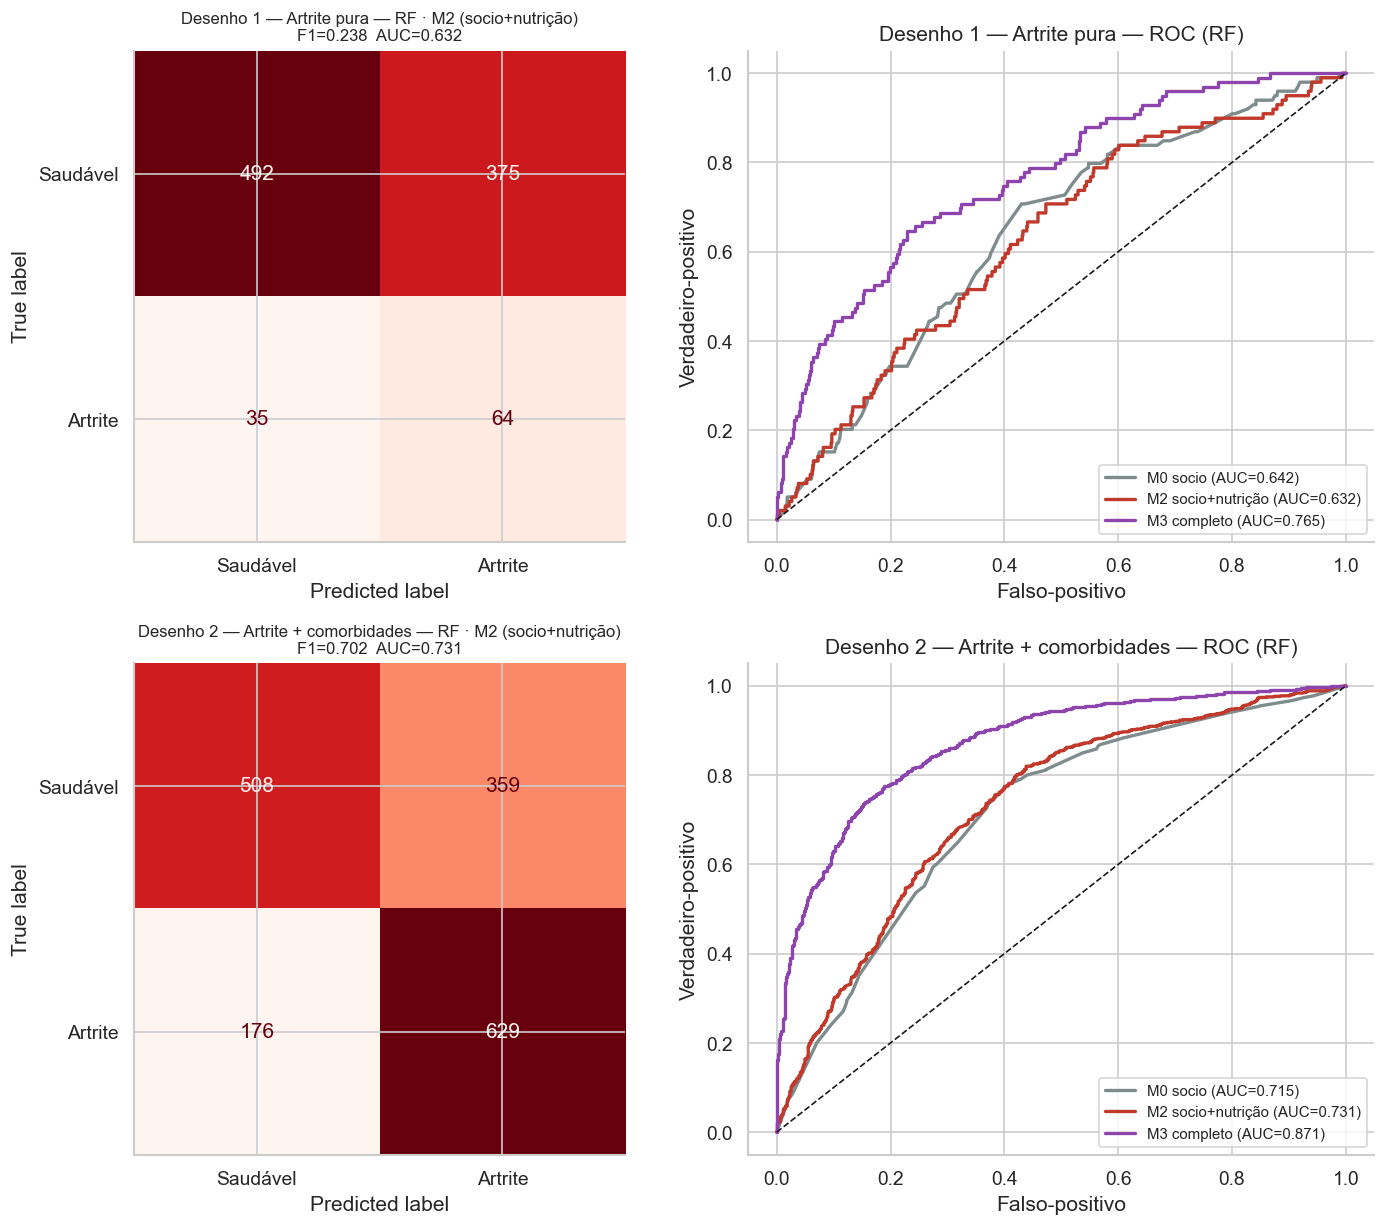

[d1] RF · M2 — classe Artrite: precisão=0.146 recall=0.646 f1=0.238 | macro-F1=0.472
[d2] RF · M2 — classe Artrite: precisão=0.637 recall=0.781 f1=0.702 | macro-F1=0.678


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(len(DESIGN), 2, figsize=(12, 5.2 * len(DESIGN)), squeeze=False)
for r, nome in enumerate(DESIGN):
    # (a) matriz de confusão — RF no conjunto-resposta M2
    h_m2 = RESULT_MOD[nome][('rf', 'M2_socio_nutri')]['holdout']
    ConfusionMatrixDisplay(h_m2['confusao'], display_labels=['Saudável', 'Artrite']).plot(
        ax=axes[r][0], colorbar=False, cmap='Reds')
    axes[r][0].set_title(f"{DESIGN[nome]['rotulo']} — RF · M2 (socio+nutrição)\n"
                         f"F1={h_m2['f1']:.3f}  AUC={h_m2['auc']:.3f}", fontsize=10)
    # (b) ROC sobreposta M0/M2/M3
    for s, cor, lab in [('M0_socio', '#7f8c8d', 'M0 socio'),
                        ('M2_socio_nutri', '#C0392B', 'M2 socio+nutrição'),
                        ('M3_completo', '#8E44AD', 'M3 completo')]:
        h = RESULT_MOD[nome][('rf', s)]['holdout']
        axes[r][1].plot(h['roc']['fpr'], h['roc']['tpr'], color=cor, lw=2,
                        label=f"{lab} (AUC={h['auc']:.3f})")
    axes[r][1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[r][1].set(xlabel='Falso-positivo', ylabel='Verdadeiro-positivo',
                   title=f"{DESIGN[nome]['rotulo']} — ROC (RF)")
    axes[r][1].legend(loc='lower right', fontsize=9)
plt.tight_layout(); salvar_fig(DIR_FIGURAS, 'modelagem_confusao_roc.png'); plt.show()

# classification report do conjunto-resposta (texto, por desenho)
for nome in DESIGN:
    rep = RESULT_MOD[nome][('rf', 'M2_socio_nutri')]['holdout']['report']
    print(f"[{nome}] RF · M2 — classe Artrite: precisão={rep['1']['precision']:.3f} "
          f"recall={rep['1']['recall']:.3f} f1={rep['1']['f1-score']:.3f} | "
          f"macro-F1={rep['macro avg']['f1-score']:.3f}")

### 4.5 · Regras da Árvore de Decisão (cobertura ≥ 10%)

Entrega descritiva central (como nos papers de TOC e AVC): regras da árvore no conjunto-resposta
**M2**, mantendo só as folhas que cobrem **≥10% do treino real**. A cobertura e a pureza são medidas
sobre o treino **desbalanceado** (não sobre a subamostra RUS) — leitura populacional honesta.
Convenção: `Variável <= 0.50` em uma dummy `_Sim`/`C006_Mulher` significa *Não* / *Homem*.

In [11]:
CLASSE_TXT = {0: 'Saudável', 1: 'Artrite'}
regras_todas = []
for nome in DESIGN:
    D = DESIGN[nome]
    pipe_dt = RESULT_MOD[nome][('dt', 'M2_socio_nutri')]['holdout']['pipe']   # DT já treinada na M2 inteira
    Xs_m2 = mdl.selecionar_X(D['Xtr'], D['conj']['M2_socio_nutri'], D['raw_cols'])
    regras = mdl.regras_arvore(pipe_dt, Xs_m2, D['ytr'], tem_nutri=True, min_cobertura=MIN_COB)
    print(f"\n══ [{nome}] {D['rotulo']} — {len(regras)} regra(s) com cobertura ≥ {MIN_COB:.0%} ══")
    for r in regras:
        usa_nutri = any(t in r['regra'] for t in ['IRNI', 'Cluster'] + sorted(D['blocos']['nutri']))
        print(f"   [{CLASSE_TXT[r['classe_modelo']]}] cobertura={r['cobertura']:.0%} pureza={r['pureza_real']:.2f}"
              f"{'  ⟵ usa nutrição' if usa_nutri else ''}\n      SE {r['regra']}")
        r2 = dict(r); r2['desenho'] = nome; r2['usa_nutricao'] = usa_nutri
        r2['classe'] = CLASSE_TXT[r['classe_modelo']]; regras_todas.append(r2)
if regras_todas:
    salvar_tab(DIR_TABELAS, pd.DataFrame(regras_todas).set_index(['desenho']), 'modelagem_regras_dt.csv')


══ [d1] Desenho 1 — Artrite pura — 2 regra(s) com cobertura ≥ 10% ══
   [Saudável] cobertura=12% pureza=0.95  ⟵ usa nutrição
      SE C006_Mulher <= 0.50 E P006_cat > 1.50 E VDD004A > 1.50
   [Saudável] cobertura=12% pureza=0.94  ⟵ usa nutrição
      SE C006_Mulher <= 0.50 E P006_cat > 1.50 E VDD004A <= 1.50 E Cluster_Alimentar > 0.50 E IRNI_graded <= 3.64

══ [d2] Desenho 2 — Artrite + comorbidades — 3 regra(s) com cobertura ≥ 10% ══
   [Artrite] cobertura=20% pureza=0.56  ⟵ usa nutrição
      SE C006_Mulher > 0.50 E C008_cat <= 0.50 E VDD004A <= 5.50 E IRNI_graded > -4.47 E P02601_Muito baixo <= 0.50
   [Saudável] cobertura=15% pureza=0.82  ⟵ usa nutrição
      SE C006_Mulher <= 0.50 E P02102_Diet/Light/Zero <= 0.50 E C008_cat <= 0.50 E P006_cat > 1.50 E IRNI_graded > -5.34
   [Artrite] cobertura=12% pureza=0.64  ⟵ usa nutrição
      SE C006_Mulher > 0.50 E C008_cat > 0.50 E IRNI_graded > -11.14 E P02401_Integral > 0.50 E P02601_Baixo <= 0.50
  ✅ Tabela → ../data/results/modelagem/t

### 4.6 · Triangulação de importância por bloco + OR ajustado

Três lentes independentes sobre *quais* atributos diferenciam, agregadas por **variável-pai** e
agrupadas por **bloco**: (1) **SU** da entropia (§3), (2) **importância Gini** da Floresta (M3
completo) e (3) **OR ajustado** (Regressão Logística `y ~ socio + IRNI + Cluster`, base sem
balancear — *diet net de sociodemográfico*). Convergência das três = fator robusto. A pergunta de
pesquisa é respondida lendo a coluna `bloco`: o peso fica em *socio* ou em *nutri*?

  ✅ Tabela → ../data/results/modelagem/tabelas/modelagem_triangulacao_d1.csv

══ [d1] Desenho 1 — Artrite pura — top 12 por importância Gini (RF · M3) ══


,SU,RF_Gini,bloco,OR,OR_ic_lo,OR_ic_hi,p
N001,0.0227,0.1528,control,NaN,NaN,NaN,NaN
C006,0.0308,0.1152,socio,2.4962,2.0482,3.0423,0.0000
J012,0.0203,0.1050,control,NaN,NaN,NaN,NaN
Q084,0.0329,0.0964,control,NaN,NaN,NaN,NaN
N010,0.0315,0.0927,control,NaN,NaN,NaN,NaN
IRNI_graded,0.0000,0.0689,nutri,0.9273,0.8145,1.0556,0.2536
G081,0.0223,0.0452,control,NaN,NaN,NaN,NaN
Q05901,0.0186,0.0409,control,NaN,NaN,NaN,NaN
J01002,0.0098,0.0396,control,NaN,NaN,NaN,NaN
N011,0.0289,0.0291,control,NaN,NaN,NaN,NaN


  ✅ Tabela → ../data/results/modelagem/tabelas/modelagem_triangulacao_d2.csv

══ [d2] Desenho 2 — Artrite + comorbidades — top 12 por importância Gini (RF · M3) ══


,SU,RF_Gini,bloco,OR,OR_ic_lo,OR_ic_hi,p
N001,0.0914,0.1663,control,NaN,NaN,NaN,NaN
J012,0.0979,0.1644,control,NaN,NaN,NaN,NaN
C006,0.1013,0.1493,socio,4.7426,4.2999,5.2308,0.0000
Q084,0.0979,0.1159,control,NaN,NaN,NaN,NaN
N010,0.0740,0.0935,control,NaN,NaN,NaN,NaN
N011,0.0808,0.0839,control,NaN,NaN,NaN,NaN
G081,0.0673,0.0489,control,NaN,NaN,NaN,NaN
J01101,0.0483,0.0328,control,NaN,NaN,NaN,NaN
IMC,0.0255,0.0303,control,NaN,NaN,NaN,NaN
IRNI_graded,0.0000,0.0162,nutri,1.0182,0.9562,1.0842,0.5744


  ✅ Figura → ../data/results/modelagem/figuras/modelagem_importancia_bloco.png


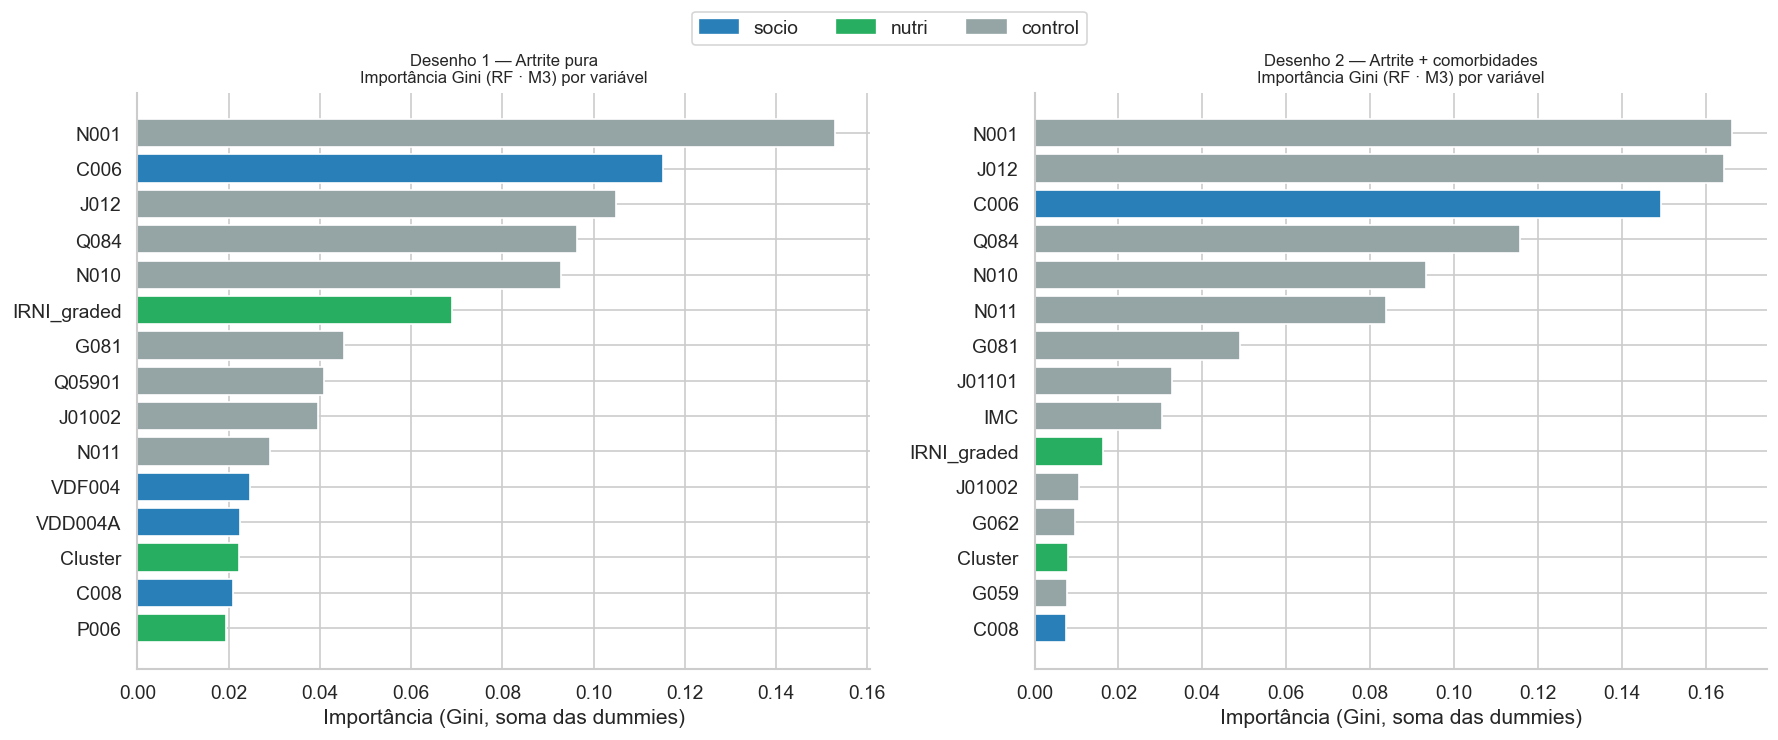

In [12]:
def _bloco_de(parent, blocos):
    if parent in ('IRNI_graded', 'IRNI_direcao', 'Cluster'):
        return 'nutri'
    for b in ('socio', 'nutri', 'control'):
        if any(mdl.var_pai(c) == parent for c in blocos.get(b, [])):
            return b
    return 'control'

CORES_BLOCO = {'socio': '#2980B9', 'nutri': '#27AE60', 'control': '#95A5A6'}
triang = {}
for nome in DESIGN:
    D = DESIGN[nome]
    # (1) SU por variável-pai (máx entre as dummies) — da §3
    su = RESULT[nome]['tabela'][['feature', 'SU']].copy()
    su['parent'] = su['feature'].map(mdl.var_pai)
    su_par = su.groupby('parent')['SU'].max()
    # (2) Gini da RF (M3 completo) por variável-pai (soma das dummies)
    pipe_rf = RESULT_MOD[nome][('rf', 'M3_completo')]['holdout']['pipe']
    nomes_rf = (pipe_rf.named_steps['nutri'].get_feature_names_out()
                if 'nutri' in pipe_rf.named_steps else
                mdl.selecionar_X(D['Xtr'], D['conj']['M3_completo'], D['raw_cols']).columns)
    gini = pd.Series(pipe_rf.named_steps['clf'].feature_importances_, index=nomes_rf)
    gini_par = gini.groupby(pd.Index(nomes_rf).map(mdl.var_pai)).sum()
    # (3) OR ajustado (socio + IRNI + Cluster) na base inteira
    Xfit = mdl.NutricaoInFold(PESOS_G, PESOS_D, k=D['k']).fit_transform(
        mdl.selecionar_X(D['X'], D['conj']['M2_socio_nutri'], D['raw_cols']))
    orr = mdl.or_ajustado(Xfit, D['y'], D['blocos']['socio'], ['IRNI_graded', 'Cluster_Alimentar'])
    orr.index = [mdl.var_pai(i) for i in orr.index]

    tri = pd.DataFrame({'SU': su_par, 'RF_Gini': gini_par}).fillna(0.0)
    tri['bloco'] = [_bloco_de(p, D['blocos']) for p in tri.index]
    tri = tri.join(orr[['OR', 'OR_ic_lo', 'OR_ic_hi', 'p']])
    tri = tri.sort_values('RF_Gini', ascending=False)
    triang[nome] = tri
    salvar_tab(DIR_TABELAS, tri, f'modelagem_triangulacao_{nome}.csv')
    print(f"\n══ [{nome}] {D['rotulo']} — top 12 por importância Gini (RF · M3) ══")
    display(tri.head(12).round(4))

# Figura: importância Gini (top 15) colorida por bloco, por desenho
fig, axes = plt.subplots(1, len(DESIGN), figsize=(7.5 * len(DESIGN), 6), squeeze=False)
for ax, nome in zip(axes[0], DESIGN):
    t = triang[nome].head(15).iloc[::-1]
    ax.barh(t.index, t['RF_Gini'], color=[CORES_BLOCO[b] for b in t['bloco']])
    ax.set_title(f"{DESIGN[nome]['rotulo']}\nImportância Gini (RF · M3) por variável", fontsize=10)
    ax.set_xlabel('Importância (Gini, soma das dummies)')
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=c, label=b) for b, c in CORES_BLOCO.items()],
           loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.04))
plt.tight_layout(); salvar_fig(DIR_FIGURAS, 'modelagem_importancia_bloco.png'); plt.show()

### 4.7 · Comparação estatística dos modelos (teste-t pareado + Bonferroni)

Os quatro algoritmos no conjunto-resposta **M2** são comparados pelas suas **F1 nos 10 folds**
(teste-t pareado, correção de Bonferroni para as comparações múltiplas). Diferença não-significativa
favorece o modelo mais interpretável (Árvore), como nos papers do grupo.

In [13]:
cmp_modelos = {}
for nome in DESIGN:
    f1f = {ROTULO_MODELO[m]: RESULT_MOD[nome][(m, 'M2_socio_nutri')]['cv']['f1_folds'] for m in COMBOS}
    tab = mdl.ttest_pareado_bonferroni(f1f, alpha=ALPHA)
    cmp_modelos[nome] = tab
    medias = {m: float(np.mean(v)) for m, v in f1f.items()}
    melhor = max(medias, key=medias.get)
    salvar_tab(DIR_TABELAS, tab.set_index(['modelo_a', 'modelo_b']), f'modelagem_ttest_{nome}.csv')
    print(f"\n══ [{nome}] {DESIGN[nome]['rotulo']} — F1 média (10-fold) por modelo (M2) ══")
    print('   ' + '  |  '.join(f'{m}={v:.3f}' for m, v in sorted(medias.items(), key=lambda x: -x[1])))
    print(f"   melhor: {melhor} ({medias[melhor]:.3f})")
    display(tab.round(4))

  ✅ Tabela → ../data/results/modelagem/tabelas/modelagem_ttest_d1.csv

══ [d1] Desenho 1 — Artrite pura — F1 média (10-fold) por modelo (M2) ══
   Regressão Logística=0.231  |  Árvore de Decisão=0.224  |  Floresta Aleatória=0.222  |  Naïve-Bayes=0.214
   melhor: Regressão Logística (0.231)


,modelo_a,modelo_b,dif_media_f1,t,p,p_bonferroni,signif_0.05
0,Floresta Aleatória,Árvore de Decisão,-0.0018,-0.1492,0.8847,1.0000,False
1,Floresta Aleatória,Naïve-Bayes,0.0086,0.8692,0.4073,1.0000,False
2,Floresta Aleatória,Regressão Logística,-0.0090,-1.7178,0.1200,0.7198,False
3,Árvore de Decisão,Naïve-Bayes,0.0105,0.7641,0.4643,1.0000,False
4,Árvore de Decisão,Regressão Logística,-0.0072,-0.7075,0.4972,1.0000,False
5,Naïve-Bayes,Regressão Logística,-0.0176,-1.8549,0.0966,0.5796,False


  ✅ Tabela → ../data/results/modelagem/tabelas/modelagem_ttest_d2.csv

══ [d2] Desenho 2 — Artrite + comorbidades — F1 média (10-fold) por modelo (M2) ══
   Floresta Aleatória=0.700  |  Regressão Logística=0.692  |  Árvore de Decisão=0.690  |  Naïve-Bayes=0.528
   melhor: Floresta Aleatória (0.700)


,modelo_a,modelo_b,dif_media_f1,t,p,p_bonferroni,signif_0.05
0,Floresta Aleatória,Árvore de Decisão,0.0096,6.1459,0.0002,0.001,True
1,Floresta Aleatória,Naïve-Bayes,0.1717,16.1880,0.0000,0.000,True
2,Floresta Aleatória,Regressão Logística,0.0079,2.9915,0.0152,0.091,False
3,Árvore de Decisão,Naïve-Bayes,0.1620,14.2520,0.0000,0.000,True
4,Árvore de Decisão,Regressão Logística,-0.0018,-0.5304,0.6087,1.000,False
5,Naïve-Bayes,Regressão Logística,-0.1638,-16.3344,0.0000,0.000,True


### 4.8 · Síntese — resposta à pergunta de pesquisa

Fecho que lê os números das seções anteriores e responde, por desenho e no conjunto, *quais
padrões nutricionais e características sociodemográficas diferenciam os idosos com artrite dos
saudáveis*. Exporta `relatorio_modelagem.json` com todos os artefatos.

In [14]:
def _or_de(nome, parent):
    t = triang[nome]
    if parent in t.index and pd.notna(t.loc[parent, 'OR']):
        r = t.loc[parent]
        return f"OR={r['OR']:.2f} [{r['OR_ic_lo']:.2f}-{r['OR_ic_hi']:.2f}] p={r['p']:.3g}"
    return "n/d"

relatorio_mod = {'notebook': '06 §4 — Ablação por blocos', 'pergunta': (
    'Quais padrões nutricionais e características sociodemográficas diferenciam idosos com '
    'artrite dos saudáveis (PNS 2019), via algoritmos supervisionados?'),
    'parametros': {'N_ITER': N_ITER, 'CV_BUSCA': CV_BUSCA, 'CV_AVAL': CV_AVAL,
                   'min_cobertura': MIN_COB, 'random_state': RANDOM_STATE},
    'desenhos': {}}

print('═' * 84)
for nome in DESIGN:
    dF1_s  = _cv(nome, 'rf', 'M2_socio_nutri', 'f1')  - _cv(nome, 'rf', 'M0_socio', 'f1')
    dAUC_s = _cv(nome, 'rf', 'M2_socio_nutri', 'auc') - _cv(nome, 'rf', 'M0_socio', 'auc')
    dF1_c  = _cv(nome, 'rf', 'M3_completo', 'f1')  - _cv(nome, 'rf', 'Mc_socio_ctrl', 'f1')
    n_regras_nutri = sum(1 for r in regras_todas if r['desenho'] == nome and r['usa_nutricao'])
    medias = {m: float(np.mean(RESULT_MOD[nome][(m, 'M2_socio_nutri')]['cv']['f1_folds'])) for m in COMBOS}
    melhor = max(medias, key=medias.get)
    relatorio_mod['desenhos'][nome] = {
        'rotulo': DESIGN[nome]['rotulo'], 'k_cluster': DESIGN[nome]['k'],
        'AUC_M0_socio': round(_cv(nome, 'rf', 'M0_socio', 'auc'), 3),
        'AUC_M1_nutri': round(_cv(nome, 'rf', 'M1_nutri', 'auc'), 3),
        'AUC_Mc_socio_ctrl': round(_cv(nome, 'rf', 'Mc_socio_ctrl', 'auc'), 3),
        'AUC_M3_completo': round(_cv(nome, 'rf', 'M3_completo', 'auc'), 3),
        'dF1_nutricao_sobre_socio': round(dF1_s, 3), 'dAUC_nutricao_sobre_socio': round(dAUC_s, 3),
        'dF1_nutricao_sobre_socio_ctrl': round(dF1_c, 3),
        'OR_IRNI': _or_de(nome, 'IRNI_graded'), 'OR_Cluster': _or_de(nome, 'Cluster'),
        'OR_sexo_mulher': _or_de(nome, 'C006'), 'OR_idade': _or_de(nome, 'C008'),
        'melhor_modelo_M2': ROTULO_MODELO[melhor], 'F1_melhor_M2': round(medias[melhor], 3),
        'n_regras_cob10_usando_nutricao': n_regras_nutri}

    print(f"[{nome}] {DESIGN[nome]['rotulo']}")
    print(f"  • Acrescentar NUTRIÇÃO ao sociodemográfico: ΔF1={dF1_s:+.3f}, ΔAUC={dAUC_s:+.3f} "
          f"(sobre socio+controle: ΔF1={dF1_c:+.3f}) → contribuição marginal ~nula.")
    print(f"  • Poder isolado: AUC só-nutrição={_cv(nome,'rf','M1_nutri','auc'):.3f} vs "
          f"só-socio={_cv(nome,'rf','M0_socio','auc'):.3f}; controle de saúde domina "
          f"(AUC Mc={_cv(nome,'rf','Mc_socio_ctrl','auc'):.3f}).")
    print(f"  • Sociodemográfico: sexo(mulher) {_or_de(nome,'C006')} · idade {_or_de(nome,'C008')}.")
    print(f"  • Nutrição ajustada: IRNI {_or_de(nome,'IRNI_graded')} · Cluster {_or_de(nome,'Cluster')}.")
    print(f"  • Regras (cob≥{MIN_COB:.0%}) que usam nutrição: {n_regras_nutri}. "
          f"Melhor modelo (M2): {ROTULO_MODELO[melhor]} F1={medias[melhor]:.3f}.\n")

with open(DIR_SAIDA + 'relatorio_modelagem.json', 'w', encoding='utf-8') as f:
    json.dump(relatorio_mod, f, ensure_ascii=False, indent=2)
print('═' * 84)
print('RESPOSTA: características SOCIODEMOGRÁFICAS (sobretudo SEXO feminino e IDADE) e o ESTADO DE')
print('SAÚDE (comorbidades/limitação) diferenciam os grupos; os PADRÕES NUTRICIONAIS têm poder')
print('discriminante FRACO e não-robusto ao ajuste — ΔF1/ΔAUC ~0 ao acrescentar a dieta. Achado')
print('coerente com a causalidade reversa e a alta imputação alimentar (Desenho 3 / spec §0).')
print(f"\n✅ Relatório → {DIR_SAIDA}relatorio_modelagem.json")

════════════════════════════════════════════════════════════════════════════════════
[d1] Desenho 1 — Artrite pura
  • Acrescentar NUTRIÇÃO ao sociodemográfico: ΔF1=-0.010, ΔAUC=+0.022 (sobre socio+controle: ΔF1=-0.002) → contribuição marginal ~nula.
  • Poder isolado: AUC só-nutrição=0.574 vs só-socio=0.603; controle de saúde domina (AUC Mc=0.720).
  • Sociodemográfico: sexo(mulher) OR=2.50 [2.05-3.04] p=1.27e-19 · idade OR=1.20 [1.05-1.38] p=0.00623.
  • Nutrição ajustada: IRNI OR=0.93 [0.81-1.06] p=0.254 · Cluster OR=1.03 [0.94-1.12] p=0.549.
  • Regras (cob≥10%) que usam nutrição: 2. Melhor modelo (M2): Regressão Logística F1=0.231.

[d2] Desenho 2 — Artrite + comorbidades
  • Acrescentar NUTRIÇÃO ao sociodemográfico: ΔF1=+0.008, ΔAUC=+0.012 (sobre socio+controle: ΔF1=+0.005) → contribuição marginal ~nula.
  • Poder isolado: AUC só-nutrição=0.618 vs só-socio=0.711; controle de saúde domina (AUC Mc=0.871).
  • Sociodemográfico: sexo(mulher) OR=4.74 [4.30-5.23] p=7.88e-213 · idade OR